# Seção 4: Modelagem com Machine Learning
## Classificação da Via de Transporte das Exportações Brasileiras (LightGBM)

Este notebook implementa o modelo LightGBM (gradient boosting) para a tarefa de modelagem preditiva do projeto, que é um dos três algoritmos comparados pelo grupo:

1. Regressão Logística (baseline linear interpretável)
2. Random Forest (ensemble por bagging)
3. LightGBM (ensemble por boosting), implementado neste notebook

### Pergunta de pesquisa (RQ2)
> É possível classificar a via de transporte principal (CO_VIA) utilizada em uma operação de exportação com base nas características físicas da carga (KG_LIQUIDO), na localização geográfica de origem (SG_UF_NCM) e no valor declarado (VL_FOB)?

### Hipótese associada (H2)
> As características físicas da carga (KG_LIQUIDO) e a localização geográfica de origem (SG_UF_NCM) são os preditores com maior peso estatístico para classificar a via de transporte (CO_VIA), superando o impacto do valor declarado (VL_FOB).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from pathlib import Path

# Configuracoes globais
RANDOM_STATE = 42
DATA_PATH = Path('../data/exports_tidy.parquet')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style='white')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print('Versoes:')
print(f'  pandas    {pd.__version__}')
print(f'  numpy     {np.__version__}')
print(f'  lightgbm  {lgb.__version__}')

Versoes:
  pandas    3.0.3
  numpy     2.4.6
  lightgbm  4.6.0


## 1. Carregamento dos dados

Usamos o dataset tidy já limpo e enriquecido na Etapa 3 (exports_tidy.parquet), contendo
1.709.746 registros de exportações brasileiras de 2025 e 23 colunas, incluindo features
derivadas como value_per_kg, origin_region, is_mercosul e is_coastal_state.

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f'Registros: {df.shape[0]:,}  |  Colunas: {df.shape[1]}')
df.head()

Registros: 1,709,746  |  Colunas: 23


,year,month,ncm_code,statistical_unit_code_export,country_code,origin_state,transport_route,urf_code,statistical_quantity,net_weight_kg,...,quarter,semester,origin_region,ncm_chapter,is_mercosul,is_coastal_state,is_express_delivery,statistical_unit_code_ncm,ncm_name_ptbr,country_name
0,2025,8,71039900,19,687,RS,4,817700,61690,13.0000,...,3,2,South,71,False,True,False,19,Outras pedras preciosas (exceto diamantes) ou ...,El Salvador
1,2025,12,2071412,10,741,SC,1,817800,83835,"83,835.0000",...,4,2,South,2,False,True,False,10,Coxas com sobrecoxas não desossadas de galinha...,Singapura
2,2025,11,33059000,10,767,SP,4,817600,792,753.0000,...,4,2,Southeast,33,False,True,False,10,Outras preparações capilares,Suíça
3,2025,11,56031330,10,845,SP,7,1017701,2437,"2,437.0000",...,4,2,Southeast,56,False,True,False,10,"Falsos tecidos de poliéster, de peso superior ...",Uruguai
4,2025,6,21069090,10,365,SP,1,817800,4800,"4,800.0000",...,2,1,Southeast,21,False,True,False,10,Outras preparações alimentícias,Indonésia


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1709746 entries, 0 to 1709745
Data columns (total 23 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   year                          int64  
 1   month                         int64  
 2   ncm_code                      int64  
 3   statistical_unit_code_export  int64  
 4   country_code                  int64  
 5   origin_state                  str    
 6   transport_route               str    
 7   urf_code                      int64  
 8   statistical_quantity          int64  
 9   net_weight_kg                 float64
 10  fob_value_usd                 float64
 11  month_name                    str    
 12  value_per_kg                  float64
 13  quarter                       int64  
 14  semester                      int64  
 15  origin_region                 str    
 16  ncm_chapter                   int64  
 17  is_mercosul                   bool   
 18  is_coastal_state              boo

## 2. Construção da variável alvo (route_class)

A coluna transport_route (CO_VIA) é fortemente desbalanceada: três modais concentram cerca de
98% dos registros, enquanto a cauda contém classes com pouquíssimas observações (algumas com
apenas 2 registros).

Decisões tomadas para tornar o problema tratável e a métrica F1-macro significativa:

1. Remover a categoria 00 (VIA NAO DECLARADA), cerca de 1% dos dados. Não é um modal real, e
   sim ausência de informação no alvo, então mantê-la poluiria o target.
2. Manter como classes próprias os modais com suporte suficiente: MARITIMA (01), AEREA (04),
   RODOVIARIA (07) e VICINAL_FRONTEIRICO (15, cerca de 20 mil registros).
3. Agrupar em OUTROS a cauda genuinamente minúscula (fluvial, lacustre, ferroviária, conduto,
   meios próprios, em mãos e por reboque), evitando classes não treináveis.

Resultado: 5 classes cobrindo cerca de 99% dos dados.

In [4]:
# Mapeamento CO_VIA -> classe alvo. Codigos nao listados caem em 'OUTROS'.
ROUTE_NAMES = {1: 'MARITIMA', 4: 'AEREA', 7: 'RODOVIARIA', 15: 'VICINAL_FRONTEIRICO'}
DROP_CODE = 0  # VIA NAO DECLARADA -> removido (alvo nao informativo)

def to_route_class(code):
    c = int(code)
    if c == DROP_CODE:
        return None
    return ROUTE_NAMES.get(c, 'OUTROS')

n_before = len(df)
df['route_class'] = df['transport_route'].map(to_route_class)
n_removed = int(df['route_class'].isna().sum())
df = df.dropna(subset=['route_class']).reset_index(drop=True)

print(f'Linhas antes: {n_before:,}')
print(f'Removidas (00, nao declarada): {n_removed:,}')
print(f'Linhas apos limpeza do alvo: {len(df):,}')

Linhas antes: 1,709,746
Removidas (00, nao declarada): 16,902
Linhas apos limpeza do alvo: 1,692,844


In [5]:
# Distribuicao das 5 classes do target
dist = df['route_class'].value_counts()
dist_pct = (dist / len(df) * 100).round(2)
dist_table = pd.DataFrame({'registros': dist, 'percentual_%': dist_pct})
dist_table

,registros,percentual_%
route_class,,
MARITIMA,913761,53.9800
AEREA,466747,27.5700
RODOVIARIA,290955,17.1900
VICINAL_FRONTEIRICO,19913,1.1800
OUTROS,1468,0.0900


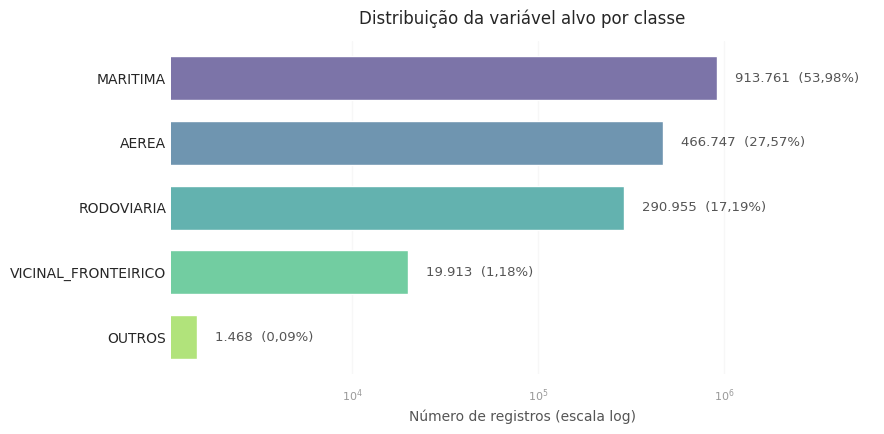

In [6]:
# Visualizacao da distribuicao (escala log para enxergar as classes raras)
def lighten(color, amount=0.3):
    """Clareia uma cor misturando-a com branco (amount em [0, 1])."""
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1.0 - c) * amount)

def br_num(v):
    """Formata inteiro no padrao brasileiro: 913761 -> 913.761."""
    return f'{v:,.0f}'.replace(',', '.')

order = dist.index.tolist()
base_colors = sns.color_palette('viridis', len(order))
colors = [lighten(c, 0.3) for c in base_colors]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(order, dist.values, color=colors, edgecolor='white', height=0.68)
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_xlim(right=dist.values.max() * 7)

for bar, v, p in zip(bars, dist.values, dist_pct.values):
    pct = f'{p:.2f}'.replace('.', ',')
    ax.text(bar.get_width() * 1.25, bar.get_y() + bar.get_height() / 2,
            f'{br_num(v)}  ({pct}%)', va='center', ha='left',
            fontsize=9.5, color='#555555')

ax.set_xlabel('Número de registros (escala log)', fontsize=10, color='#555555')
ax.set_title('Distribuição da variável alvo por classe', fontsize=12, pad=12)
ax.tick_params(axis='y', length=0, labelsize=10)
ax.tick_params(axis='x', colors='#999999', labelsize=8)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', alpha=0.15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'target_distribution.png', dpi=140, bbox_inches='tight')
plt.show()

Interpretação. A classe MARITIMA sozinha responde por cerca de 54% das operações, e as três
principais (MARITIMA, AEREA e RODOVIARIA) somam cerca de 98,7%. As classes VICINAL_FRONTEIRICO
(cerca de 1,2%) e sobretudo OUTROS (cerca de 0,1%) são minoritárias. Esse desbalanceamento
justifica as escolhas do contrato de modelagem:

1. Usar F1-macro, que trata todas as classes igualmente, em vez de acurácia, que seria inflada
   pela classe majoritária.
2. Aplicar balanceamento de classes no treino do modelo.
3. Usar divisão estratificada, garantindo que mesmo as classes raras apareçam em treino e teste.

## 3. Feature Engineering e Divisão Treino e Teste

Selecionamos 8 features, uma para cada conceito relevante para o modal de transporte. Evitamos variáveis redundantes ou derivadas umas das outras, que dividiriam a importância e atrapalhariam a interpretação da H2.

Numéricas:
- net_weight_kg: peso da carga (preditor central da H2)
- fob_value_usd: valor declarado (preditor central da H2)
- value_per_kg: valor por kg, a densidade de valor da carga

Categóricas (o LightGBM trata categóricas nativamente, sem one-hot encoding):
- origin_state: origem geográfica (preditor central da H2)
- country_code: país de destino
- ncm_chapter: tipo de produto
- month: mês da operação
- statistical_unit_code_export: unidade de medida da carga

Ficaram de fora o alvo, as variáveis redundantes e o urf_code, que é praticamente um proxy do modal e causaria vazamento de alvo.

Divisão: 80/20 estratificada por classe, com random_state 42.

In [7]:
# Features selecionadas para o modelo
NUMERIC_FEATURES = [
    'net_weight_kg',
    'fob_value_usd',
    'value_per_kg',
]

CATEGORICAL_FEATURES = [
    'origin_state',
    'country_code',
    'ncm_chapter',
    'month',
    'statistical_unit_code_export',
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'route_class'

print(f'Total de features: {len(FEATURES)}')
print(f'  numericas:   {len(NUMERIC_FEATURES)}')
print(f'  categoricas: {len(CATEGORICAL_FEATURES)}')

Total de features: 8
  numericas:   3
  categoricas: 5


In [8]:
# Monta X e y. Converte categoricas para o tipo 'category' (LightGBM usa particionamento nativo).
X = df[FEATURES].copy()
for col in CATEGORICAL_FEATURES:
    X[col] = X[col].astype('category')
y = df[TARGET].astype('category')

# Ordem fixa das classes, da majoritaria para a minoritaria, usada em relatorios e matrizes de confusao
CLASS_ORDER = ['MARITIMA', 'AEREA', 'RODOVIARIA', 'VICINAL_FRONTEIRICO', 'OUTROS']

print('Tipos das features:')
print(X.dtypes)

Tipos das features:
net_weight_kg                    float64
fob_value_usd                    float64
value_per_kg                     float64
origin_state                    category
country_code                    category
ncm_chapter                     category
month                           category
statistical_unit_code_export    category
dtype: object


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f'Treino: {X_train.shape[0]:,} linhas')
print(f'Teste:  {X_test.shape[0]:,} linhas')

Treino: 1,354,275 linhas
Teste:  338,569 linhas


In [10]:
# Confirma que a estratificacao preservou as proporcoes das classes entre treino e teste
check = pd.DataFrame({
    'treino_n': y_train.value_counts().reindex(CLASS_ORDER),
    'treino_%': (y_train.value_counts(normalize=True) * 100).round(2).reindex(CLASS_ORDER),
    'teste_n': y_test.value_counts().reindex(CLASS_ORDER),
    'teste_%': (y_test.value_counts(normalize=True) * 100).round(2).reindex(CLASS_ORDER),
})
check

,treino_n,treino_%,teste_n,teste_%
route_class,,,,
MARITIMA,731009,53.9800,182752,53.9800
AEREA,373398,27.5700,93349,27.5700
RODOVIARIA,232764,17.1900,58191,17.1900
VICINAL_FRONTEIRICO,15930,1.1800,3983,1.1800
OUTROS,1174,0.0900,294,0.0900
